## Sympy

The ODE is:


Eq(D*Derivative(p(x), (x, 2)) - v*Derivative(p(x), x), 0)

Eq(10*D*S*Derivative(p(x), x) + D*Derivative(p(x), (x, 2)) - v*Derivative(p(x), x), 0)


The general solution is:


Eq(p(x), C1 + C2*exp(v*x/D))

...

{C1: -1/(exp(v/D) - 1), C2: 1/(exp(v/D) - 1)}

{C1: exp(10*S)/(exp(10*S) - exp(v/D)), C2: -exp(10*S)/(exp(10*S) - exp(v/D))}


The final solution is:


(1 - exp(v*x/D))/(1 - exp(v/D))

(exp(10*S*x) - exp(v*x/D))*exp(10*S*(1 - x))/(exp(10*S) - exp(v/D))

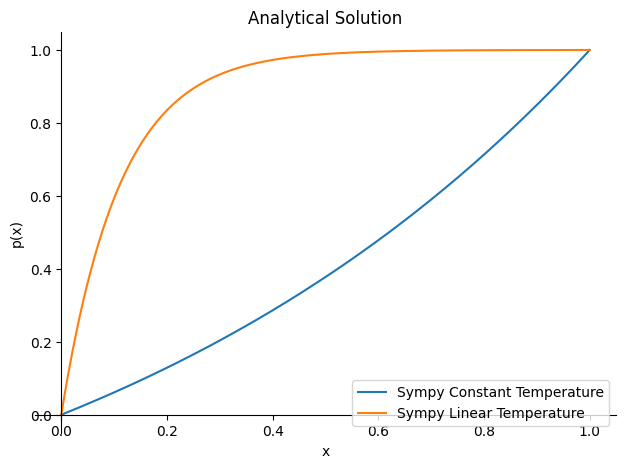

In [134]:
import sympy as sp

x_sym = sp.symbols('x')
D, v, S = sp.symbols('D v S')
p_sympy_const = sp.Function('p')(x_sym)
p_sympy_lin = sp.Function('p')(x_sym)

T1 = 300
T2 = T1 + 10 * x_sym

ode_const = sp.Eq(D * sp.diff(p_sympy_const, x_sym, 2) - v * sp.diff(p_sympy_const, x_sym) + D * S * sp.diff(p_sympy_const * sp.diff(T1, x_sym), x_sym), 0)
ode_lin = sp.Eq(D * sp.diff(p_sympy_lin, x_sym, 2) - v * sp.diff(p_sympy_lin, x_sym) + D * S * sp.diff(p_sympy_lin * sp.diff(T2, x_sym), x_sym), 0)
print("The ODE is:")
display(sp.simplify(ode_const))
display(sp.simplify(ode_lin))

solution_const = sp.dsolve(ode_const, p_sympy_const)
solution_lin = sp.dsolve(ode_lin, p_sympy_lin)

print("\nThe general solution is:")
display(solution_const)
display(solution_lin)

p_sol_const = solution_const.rhs
p_sol_lin = solution_lin.rhs
bc1 = sp.Eq(p_sol_const.subs(x_sym, 0), 0)  
bc2 = sp.Eq(p_sol_const.subs(x_sym, 1), 1)  
bc3 = sp.Eq(p_sol_lin.subs(x_sym, 0), 0)  
bc4 = sp.Eq(p_sol_lin.subs(x_sym, 1), 1)

C1, C2 = sp.symbols('C1 C2')
constants1 = sp.solve([bc1, bc2], (C1, C2))
constants2 = sp.solve([bc3, bc4], (C1, C2))
print("\nThe constants are:")
display(sp.simplify(constants1))
display(sp.simplify(constants2))

p_sympy_const = sp.simplify(p_sol_const.subs(constants1))
p_sympy_lin = sp.simplify(p_sol_lin.subs(constants2))
print("\nThe final solution is:")
display(p_sympy_const)
display(p_sympy_lin)

p_sympy_func_const = sp.lambdify(x_sym, p_sympy_const.subs({D:1.0, v:1.0, S:1.0}), "numpy") 
p_sympy_func_lin = sp.lambdify(x_sym, p_sympy_lin.subs({D:1.0, v:1.0, S:1.0}), "numpy")

sympy_plot = sp.plot(p_sympy_const.subs({D:1.0, v:1.0, S:1.0}), p_sympy_lin.subs({D:1.0, v:1.0, S:1.0}), (x_sym, 0, 1), title='Analytical Solution', xlabel='x', ylabel='p(x)', legend=True, show=False)
sympy_plot[0].label = 'Sympy Constant Temperature'
sympy_plot[1].label = 'Sympy Linear Temperature'
sympy_plot.show()



## Fipy 

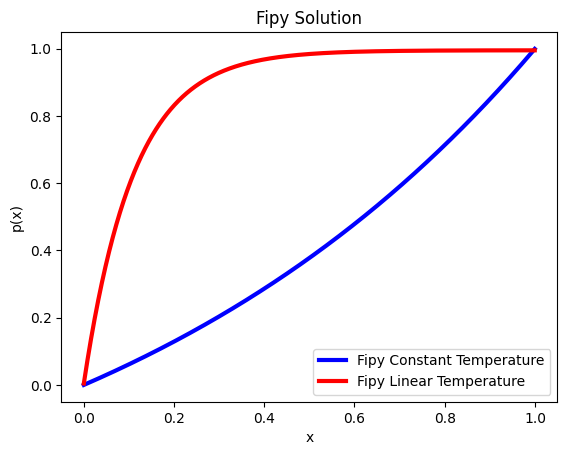

In [135]:
from fipy import CellVariable, FaceVariable, Grid1D, TransientTerm, DiffusionTerm, PowerLawConvectionTerm, Viewer
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

L = 1.0  
nx = 1000  
dx = L / nx  
mesh = Grid1D(nx=nx, dx=dx)

D, v, S = 1.0, 1.0, 1.0 

x = mesh.cellCenters[0]

T1 = CellVariable(name="Temperature", mesh=mesh, value=300.0)
T2 = CellVariable(name="Temperature", mesh=mesh, value=T1 + 10 * x)

p_const = CellVariable(name="Carrier Concentration", mesh=mesh, value=0.0)
p_lin = CellVariable(name="Carrier Concentration", mesh=mesh, value=0.0)

p_const.constrain(0.0, mesh.facesLeft)
p_const.constrain(1.0, mesh.facesRight)
p_lin.constrain(0.0, mesh.facesLeft)
p_lin.constrain(1.0, mesh.facesRight)

v = FaceVariable(mesh=mesh, rank = 1, value=1.0)

eq_const = (DiffusionTerm(coeff=D)  == PowerLawConvectionTerm(coeff=(v),) - PowerLawConvectionTerm(coeff = D * S * T1.faceGrad))
eq_lin = (DiffusionTerm(coeff=D)  == PowerLawConvectionTerm(coeff=(v),) - PowerLawConvectionTerm(coeff = D * S * T2.faceGrad))
eq_const.solve(var=p_const)
eq_lin.solve(var=p_lin)

plt.plot(x, p_const.value, label='Fipy Constant Temperature', color='blue', linewidth=3)
plt.plot(x, p_lin.value, label='Fipy Linear Temperature', color='red', linewidth=3)
plt.title('Fipy Solution')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend()
plt.show()

## Error Calculation

In [136]:
error_const = np.abs(p_const.value - p_sympy_func_const(x.value))
print("Maximum error_const:", np.max(error_const))
print("Mean error_const:", np.mean(error_const))
print("L2 error_const:", np.sqrt(np.mean(error_const**2)))
print ("\n")
error_lin = np.abs(p_lin.value - p_sympy_func_lin(x.value))
print("Maximum error_lin:", np.max(error_lin))
print("Mean error_lin:", np.mean(error_lin))
print("L2 error_lin:", np.sqrt(np.mean(error_lin**2)))

Maximum error_const: 1.0055268784281424e-08
Mean error_const: 6.600597355297007e-09
L2 error_const: 7.263292083160902e-09


Maximum error_lin: 0.004976358141616899
Mean error_lin: 0.004423154505515251
L2 error_lin: 0.004543018853944201


## Plot Comparison


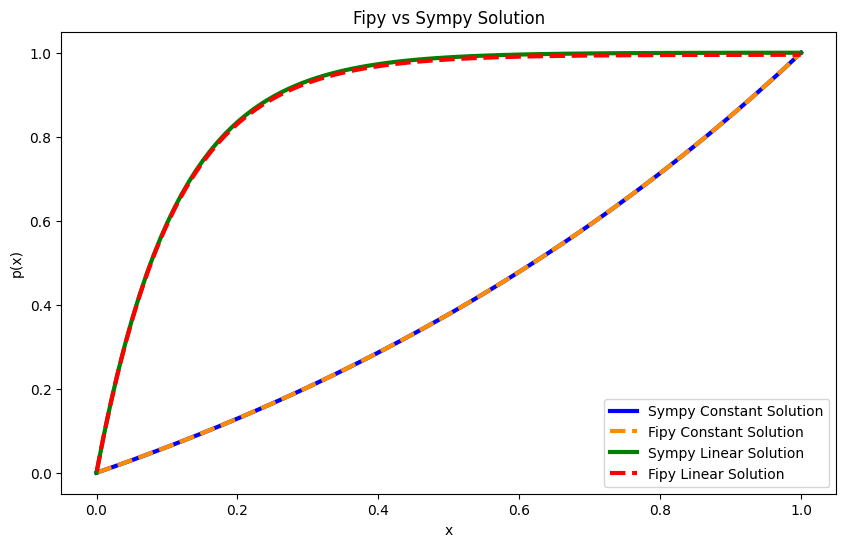

In [137]:
import matplotlib.pyplot as plt

x_exact = np.linspace(0, 1, 100)
p_exact_const = p_sympy_func_const(x_exact)
p_exact_lin = p_sympy_func_lin(x_exact)

plt.figure(figsize=(10, 6))

plt.plot(x_exact, p_exact_const, label='Sympy Constant Solution', color='blue', linewidth=3)
plt.plot(x.value, p_const.value, '--', label='Fipy Constant Solution', color='darkorange', linewidth=3)
plt.plot(x_exact, p_exact_lin, label='Sympy Linear Solution', color='green', linewidth=3)
plt.plot(x.value, p_lin.value, '--', label='Fipy Linear Solution', color='red', linewidth=3)
plt.title('Fipy vs Sympy Solution')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend()
plt.show()